In [1]:
import os
import cv2
import torch
import random
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import mediapipe as mp

# Define your class mappings
class_map = {'punch': 0, 'kick': 1, 'downtime': 2}

# Set up MediaPipe for pose detection
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5, min_tracking_confidence=0.5)

# Create transformations for data augmentation
# augment_transformation = transforms.Compose([
#     transforms.ToPILImage(),
#     transforms.RandomHorizontalFlip(p=0.5),  # Simulate realistic variations
#     transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Handle lighting differences
#     transforms.Resize((224, 224)),  # Ensure consistent size
#     transforms.ToTensor(),
#     transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
# ])

class PunchingBagDataset(Dataset):
    def __init__(self, data_dir, max_frames=16, transform=None, indices=None):
        self.data_dir = data_dir
        self.max_frames = max_frames  # Max number of frames to extract per video
        self.transform = transform
        self.data = []
        
        # Collect all video files and labels based on folders
        for class_name, class_idx in class_map.items():
            class_folder = os.path.join(data_dir, class_name)
            for file_name in os.listdir(class_folder):
                if file_name.endswith('.mov'):
                    self.data.append((os.path.join(class_folder, file_name), class_idx))

        if indices is not None:
            self.data = [self.data[i] for i in indices]
    
    def __len__(self):
        return len(self.data)

    def augment_downtime(self, keypoints):
        """
        Augments downtime keypoints by randomly zeroing out keypoints to simulate no movement.
        """
        for frame in range(keypoints.size(0)):
            if random.random() < 0.5:  # 50% chance to zero out this frame
                keypoints[frame] = torch.zeros((33, 3), dtype=torch.float32)
        return keypoints

    def __getitem__(self, idx):
        video_path, label = self.data[idx]
        pose_keypoints = []

        # Load the video using OpenCV
        cap = cv2.VideoCapture(video_path)
        frame_count = 0

        while cap.isOpened() and frame_count < self.max_frames:
            ret, frame = cap.read()
            if not ret:
                break

            # Convert frame to RGB
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Perform pose estimation
            results = pose.process(frame_rgb)
            
            if results.pose_landmarks:
                # Extract keypoints (x, y, z coordinates for 3D modeling)
                keypoints = torch.tensor([(lm.x, lm.y, lm.z) for lm in results.pose_landmarks.landmark], dtype=torch.float32)
            else:
                keypoints = torch.zeros((33, 3), dtype=torch.float32)  # Placeholder for downtime frame
            pose_keypoints.append(keypoints)

            frame_count += 1

        cap.release()

        # Pad keypoints if less than max_frames
        if len(pose_keypoints) < self.max_frames:
            pose_keypoints += [torch.zeros((33, 3), dtype=torch.float32)] * (self.max_frames - len(pose_keypoints))

        # Stack keypoints into a tensor
        pose_keypoints = torch.stack(pose_keypoints)  # Shape: (max_frames, 33, 3)

        # Apply downtime augmentation if the label is downtime
        if label == 2:  # Downtime
            pose_keypoints = self.augment_downtime(pose_keypoints)

        return pose_keypoints, label




In [2]:
import torch
import torch.nn as nn

class PoseEmbeddingNet(nn.Module):
    def __init__(self, input_dim=33*3, embedding_dim=128):
        super(PoseEmbeddingNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, embedding_dim),
            nn.ReLU()
        )

    def forward(self, x):
        # Average over frames (dim=1) to aggregate frame-level embeddings
        x = x.mean(dim=1)  # Shape becomes [batch_size, 33*3]
        x = x.view(x.size(0), -1)  # Flatten the keypoints for each sample
        
        
        # Handle all-zero keypoints (downtime)
        downtime_mask = (x.sum(dim=1) == 0).unsqueeze(1)  # Identify downtime inputs
        embeddings = self.network(x)

        # Replace downtime inputs with a learned downtime embedding
        if hasattr(self, "downtime_embedding"):
            embeddings = torch.where(downtime_mask, self.downtime_embedding, embeddings)

        return embeddings


In [3]:
class PrototypicalLoss(nn.Module):
    def __init__(self, distance_metric='euclidean'):
        super(PrototypicalLoss, self).__init__()
        self.distance_metric = distance_metric

    def forward(self, support_embeddings, support_labels, query_embeddings, query_labels):
        # Ensure correct shapes
        assert support_embeddings.size(0) == support_labels.size(0), (
            f"Mismatch in support embeddings and labels size. "
            f"support_embeddings size: {support_embeddings.size(0)}, "
            f"support_labels size: {support_labels.size(0)}"
        )

        # Step 1: Compute class prototypes
        prototypes = []
        unique_labels = torch.unique(support_labels)  # Unique class labels in support set

        for label in unique_labels:
            # Get embeddings for the current class
            mask = (support_labels == label).nonzero(as_tuple=True)[0]  # Indices for the current class
            class_embeddings = support_embeddings[mask]
            prototype = class_embeddings.mean(dim=0)  # Mean embedding for the class
            prototypes.append(prototype)

        prototypes = torch.stack(prototypes)  # Shape: [num_classes, embedding_dim]

        # Step 2: Compute distances between query embeddings and prototypes
        dists = torch.cdist(query_embeddings, prototypes)  # Shape: [num_queries, num_classes]

        # Step 3: Compute softmax probabilities and loss
        log_p = torch.log_softmax(-dists, dim=1)  # Negative distances for softmax
        loss = nn.CrossEntropyLoss()(log_p, query_labels)

        return loss, log_p



In [4]:
def pad_batch(keypoints, labels, required_size, num_classes):
    """
    Pads the batch to ensure enough samples for support and query sets.
    Args:
        keypoints (torch.Tensor): Keypoint tensor of shape [batch_size, max_frames, 33, 3].
        labels (torch.Tensor): Label tensor of shape [batch_size].
        required_size (int): Total samples required (support + query).
        num_classes (int): Number of action classes.
    Returns:
        padded_keypoints (torch.Tensor): Padded keypoints of shape [required_size, max_frames, 33, 3].
        padded_labels (torch.Tensor): Padded labels of shape [required_size].
    """
    current_size = keypoints.size(0)
    if current_size >= required_size:
        return keypoints, labels

    padding_needed = required_size - current_size

    # Create padding tensors
    pad_keypoints = torch.zeros((padding_needed, keypoints.size(1), keypoints.size(2), keypoints.size(3)), device=keypoints.device)
    pad_labels = torch.full((padding_needed,), num_classes - 1, device=labels.device, dtype=labels.dtype)  # Default to downtime (label 2)

    # Concatenate original and padding tensors
    padded_keypoints = torch.cat([keypoints, pad_keypoints], dim=0)
    padded_labels = torch.cat([labels, pad_labels], dim=0)

    return padded_keypoints, padded_labels



In [5]:
import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam

# Dataset parameters
data_dir = "./dataset" 
batch_size = 24  # Number of episodes per batch
num_classes = 3  # Number of action classes (e.g., punch, kick, downtime)
num_support = 5  # Number of support samples per class
num_query = 3    # Number of query samples per class
embedding_dim = 128

# Load dataset
dataset = PunchingBagDataset(data_dir=data_dir, max_frames=16)
num_samples = len(dataset)
train_size = int(0.8 * num_samples)
val_size = num_samples - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define model, loss, and optimizer
model = PoseEmbeddingNet(input_dim=33*3, embedding_dim=embedding_dim).to(device)
criterion = PrototypicalLoss()
optimizer = Adam(model.parameters(), lr=1e-3)

# Training loop
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:
        keypoints, labels = batch
        keypoints, labels = keypoints.to(device), labels.to(device)

        # Ensure batch has enough samples for support and query sets
        required_size = (num_support + num_query) * num_classes
        if keypoints.size(0) < required_size:
            print(f"Skipping batch with insufficient samples: {keypoints.size(0)} < {required_size}")
            continue

        # Split batch into support and query sets
        support_keypoints = keypoints[:num_support * num_classes]
        support_labels = labels[:num_support * num_classes]
        query_keypoints = keypoints[num_support * num_classes:]
        query_labels = labels[num_support * num_classes:]

        

        # Validate labels
        if not (support_labels < num_classes).all() or not (query_labels < num_classes).all():
            print(f"Skipping batch due to invalid labels: support_labels={support_labels}, query_labels={query_labels}")
            continue

        # Embed support and query keypoints
        support_embeddings = model(support_keypoints)
        query_embeddings = model(query_keypoints)

        if not (support_labels >= 0).all() or not (support_labels < num_classes).all():
            print(f"Skipping batch with invalid support labels: {support_labels}")
            continue
        if not (query_labels >= 0).all() or not (query_labels < num_classes).all():
            print(f"Skipping batch with invalid query labels: {query_labels}")
            continue



        # Compute loss and log probabilities
        loss, log_p = criterion(support_embeddings, support_labels, query_embeddings, query_labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate metrics
        total_loss += loss.item()
        preds = torch.argmax(log_p, dim=1)
        correct += (preds == query_labels).sum().item()
        total += query_labels.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total * 100 if total > 0 else 0

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")








c:\Users\bpohl\anaconda3\envs\aml\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Skipping batch with insufficient samples: 12 < 24
Epoch 1/15, Loss: 0.7968, Accuracy: 47.62%


KeyboardInterrupt: 

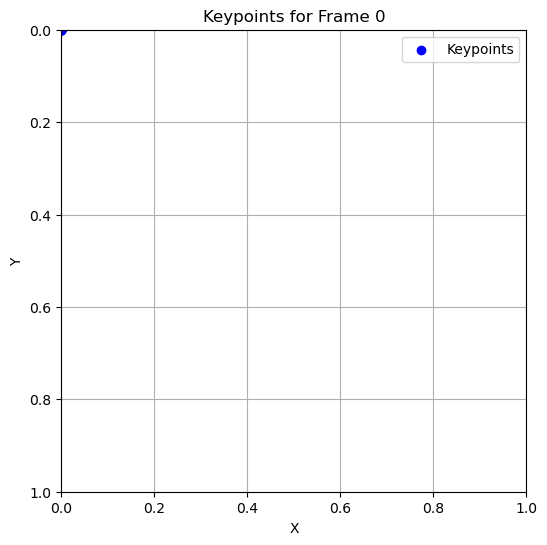

In [ ]:
import matplotlib.pyplot as plt

def visualize_keypoints(keypoints, frame_idx=0):
    """
    Visualize the keypoints for a given frame.

    Args:
        keypoints (torch.Tensor): Tensor of keypoints with shape (max_frames, 33, 3).
        frame_idx (int): Index of the frame to visualize.
    """
    # Extract the frame's keypoints
    frame_keypoints = keypoints[frame_idx, :, :2].cpu().numpy()  # Use only x, y for visualization

    # Plot the keypoints
    plt.figure(figsize=(6, 6))
    plt.scatter(frame_keypoints[:, 0], frame_keypoints[:, 1], c='blue', label='Keypoints')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.gca().invert_yaxis()  # Invert y-axis to match the image coordinate system
    plt.title(f"Keypoints for Frame {frame_idx}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid()
    plt.show()

# Example usage
for keypoints, labels in train_loader:
    keypoints, labels = keypoints.to(device), labels.to(device)
    visualize_keypoints(keypoints[0])  # Visualize the first sample in the batch
    break


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Initialize confusion matrix
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    total_loss = 0
    correct = 0
    total = 0

    for batch in val_loader:
        keypoints, labels = batch
        keypoints, labels = keypoints.to(device), labels.to(device)

        # Split batch into support and query sets
        support_keypoints = keypoints[:num_support * num_classes]
        support_labels = labels[:num_support * num_classes]
        query_keypoints = keypoints[num_support * num_classes:]
        query_labels = labels[num_support * num_classes:]

        # Embed support and query keypoints
        support_embeddings = model(support_keypoints)
        query_embeddings = model(query_keypoints)

        # Compute loss and log probabilities
        loss, log_p = criterion(support_embeddings, support_labels, query_embeddings, query_labels)

        total_loss += loss.item()
        preds = torch.argmax(log_p, dim=1)
        correct += (preds == query_labels).sum().item()
        total += query_labels.size(0)

        # Collect predictions and labels for confusion matrix
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(query_labels.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total * 100 if total > 0 else 0

    print(f"Validation Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Compute confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))

print("\nConfusion Matrix:")
print(conf_matrix)





Validation Loss: 0.4067, Accuracy: 80.00%

Confusion Matrix:
[[4 2 0]
 [1 3 0]
 [0 0 5]]


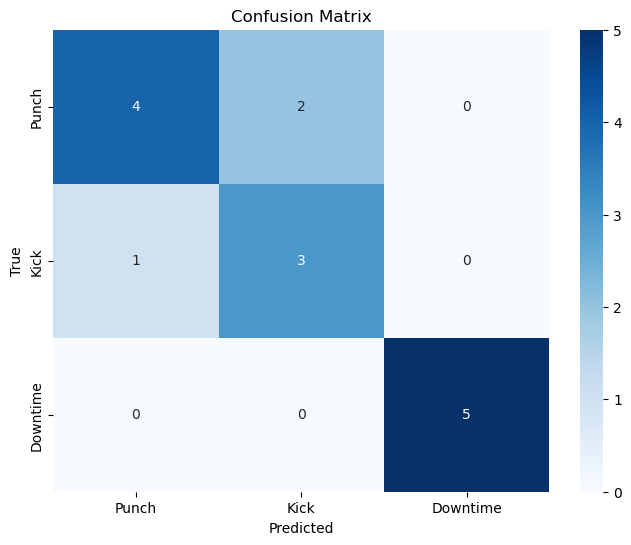

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(conf_matrix, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

# Plot confusion matrix
class_names = ['Punch', 'Kick', 'Downtime']  # Adjust based on your classes
plot_confusion_matrix(conf_matrix, class_names)


c:\Users\bpohl\anaconda3\envs\aml\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Validation Loss: 0.4059, Accuracy: 80.00%

Confusion Matrix:
[[4 2 0]
 [1 3 0]
 [0 0 5]]


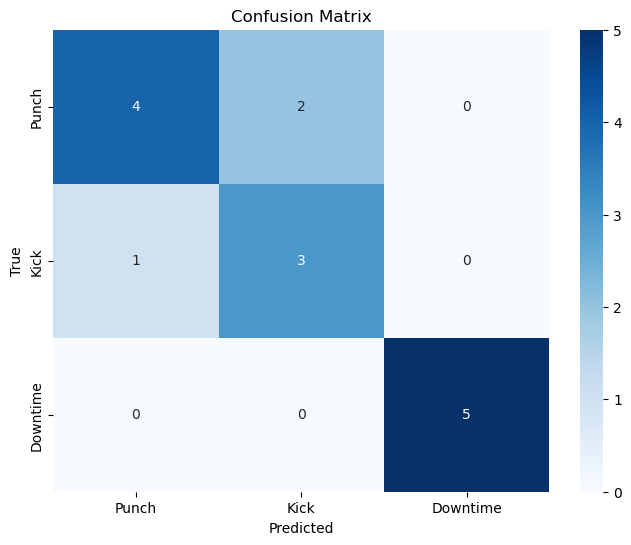


AUC Scores:
Punch: 0.9074
Kick: 0.8409
Downtime: 1.0000


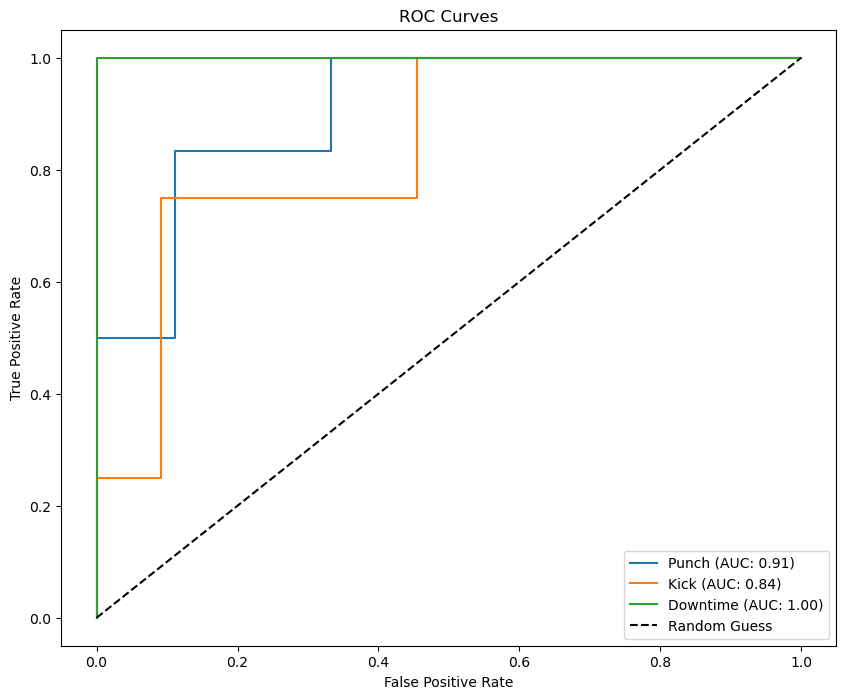

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Initialize variables for AUC
all_probs = []  # To store probabilities
all_labels = []  # To store true labels
all_preds = []   # To store predicted labels

model.eval()
with torch.no_grad():
    total_loss = 0
    correct = 0
    total = 0

    for batch in val_loader:
        keypoints, labels = batch
        keypoints, labels = keypoints.to(device), labels.to(device)

        # Split batch into support and query sets
        support_keypoints = keypoints[:num_support * num_classes]
        support_labels = labels[:num_support * num_classes]
        query_keypoints = keypoints[num_support * num_classes:]
        query_labels = labels[num_support * num_classes:]

        # Embed support and query keypoints
        support_embeddings = model(support_keypoints)
        query_embeddings = model(query_keypoints)

        # Compute loss and log probabilities
        loss, log_p = criterion(support_embeddings, support_labels, query_embeddings, query_labels)

        total_loss += loss.item()
        probs = torch.softmax(log_p, dim=1)  # Predicted probabilities
        preds = torch.argmax(probs, dim=1)  # Predicted labels

        correct += (preds == query_labels).sum().item()
        total += query_labels.size(0)

        # Collect predictions, probabilities, and labels for confusion matrix and AUC
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(query_labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total * 100 if total > 0 else 0

    print(f"Validation Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Compute confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))

print("\nConfusion Matrix:")
print(conf_matrix)

# Plot confusion matrix
def plot_confusion_matrix(conf_matrix, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

class_names = ['Punch', 'Kick', 'Downtime']
plot_confusion_matrix(conf_matrix, class_names)

# Compute and plot AUC for each class
all_probs = np.array(all_probs)
all_labels_one_hot = np.eye(num_classes)[all_labels]  # Convert labels to one-hot encoding

# Calculate AUC for each class
auc_values = {}
for i in range(num_classes):
    try:
        auc_score = roc_auc_score(all_labels_one_hot[:, i], all_probs[:, i])
        auc_values[class_names[i]] = auc_score
    except ValueError:
        auc_values[class_names[i]] = None  # Handle cases where a class has no true positives

print("\nAUC Scores:")
for class_name, auc_score in auc_values.items():
    print(f"{class_name}: {auc_score:.4f}" if auc_score is not None else f"{class_name}: Not Defined (Insufficient Data)")

# Plot ROC curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    if auc_values[class_names[i]] is not None:
        fpr, tpr, _ = roc_curve(all_labels_one_hot[:, i], all_probs[:, i])
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC: {auc_values[class_names[i]]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.show()
